In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Läs in data
df = pd.read_csv('influensa.csv', sep=';')

# Visa de första raderna och grundläggande information
print("Första raderna i datasetet:")
print(df.head())
print("\nDataset information:")
print(df.info())

Första raderna i datasetet:
        Datum      Vårdform         Mått   DATA
0  2015-07-09    Slutenvård        Antal    0.0
1  2015-07-09    Slutenvård  Per 100 000  0.000
2  2015-07-09  Intensivvård        Antal    0.0
3  2015-07-09  Intensivvård  Per 100 000  0.000
4  2015-07-16    Slutenvård        Antal    0.0

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Datum     2040 non-null   object
 1   Vårdform  2040 non-null   object
 2   Mått      2040 non-null   object
 3   DATA      2040 non-null   object
dtypes: object(4)
memory usage: 63.9+ KB
None


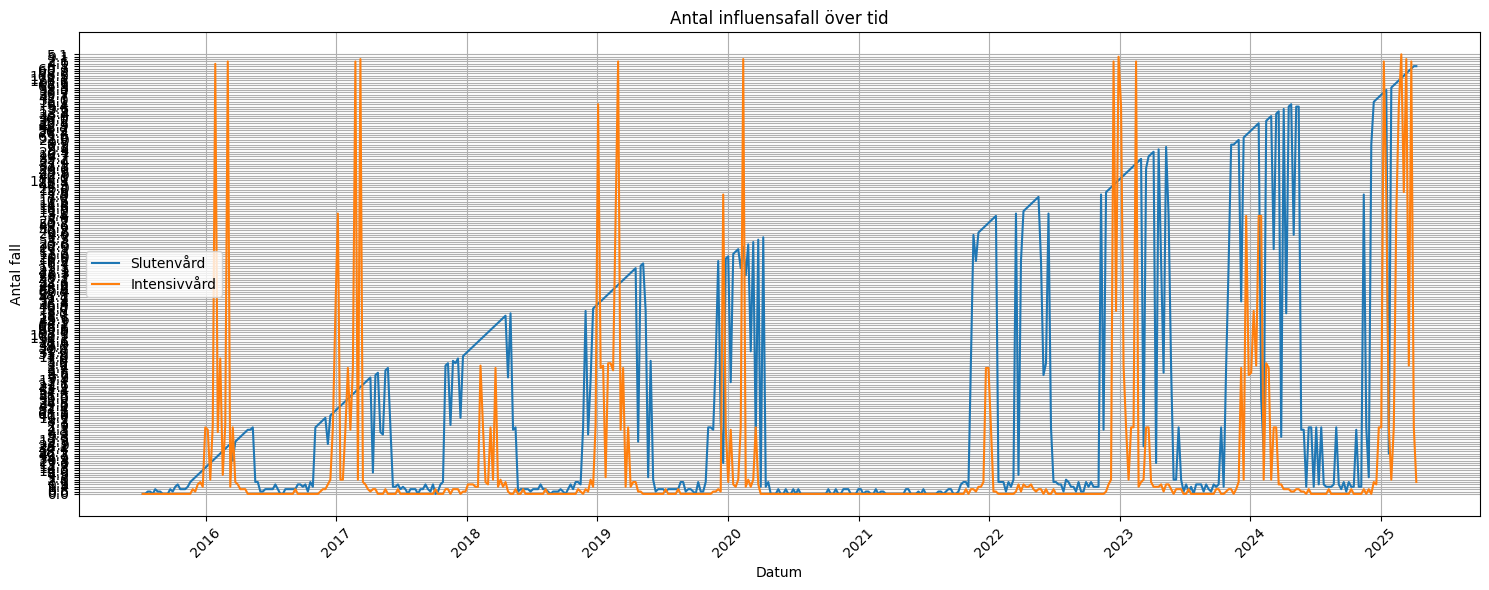

In [3]:
# Konvertera datum till datetime
df['Datum'] = pd.to_datetime(df['Datum'])

# Skapa en figur med två linjer
plt.figure(figsize=(15, 6))
for vardform in ['Slutenvård', 'Intensivvård']:
    data = df[df['Vårdform'] == vardform]
    data = data[data['Mått'] == 'Antal']
    plt.plot(data['Datum'], data['DATA'], label=vardform)

plt.title('Antal influensafall över tid')
plt.xlabel('Datum')
plt.ylabel('Antal fall')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
vardformer = df["Vårdform"].unique().tolist()
vardformer

['Slutenvård', 'Intensivvård']

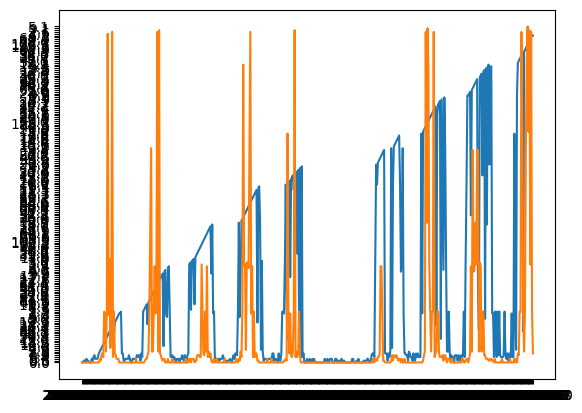

In [11]:
for vardform in vardformer:
    data = df[df["Vårdform"] == vardform]
    data = data[data["Mått"] == "Antal"]
    plt.plot(data['Datum'], data['DATA'], label=vardform)

In [17]:
import duckdb
import pandas as pd

df = pd.read_csv('influensa.csv', sep=';')

query = duckdb.query("""
    SELECT
        "Vårdform",
        COUNT(*) as antal_rader,
        AVG(
            CASE
                WHEN "DATA" = '.' THEN NULL
                ELSE CAST("DATA" AS FLOAT)
            END
        ) as medelvarde
    FROM df
    WHERE "Mått" = 'Antal'
    GROUP BY "Vårdform"
""").df()

query


,Vårdform,antal_rader,medelvarde
0,Intensivvård,510,0.716667
1,Slutenvård,510,12.736024
